# 🛠️ 02 - Veri Ön İşleme (Time Series Preprocessing)
## Uydu Telemetri Anomali Tespiti

**Amaç:** EDA aşamasında keşfedilen yapıya uygun olarak telemetri verilerini makine öğrenmesi modelleri için hazırlamak.

### Adımlar:
1. Veri Yükleme ve Ham Veri Doğrulama
2. Eksik Veri İşleme
3. Gürültü Temizleme (Filtreleme)
4. Outlier Tespiti ve Kırpma
5. Normalizasyon ve Ölçeklendirme
6. Zaman Serisi Segmentasyonu
7. Veri Dengeleme (SMOTE)
8. Train/Validation/Test Split
9. İşlenmiş Veriyi Kaydetme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import warnings
import os
import sys

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Kendi preprocessor modülümüzü import ediyoruz
sys.path.insert(0, '..')
from src.preprocessor import TelemetriPreprocessor

print('✅ Kütüphaneler ve Preprocessor yüklendi.')

✅ Kütüphaneler ve Preprocessor yüklendi.


---
## 📥 Bölüm 1: Veri Yükleme ve Ham Veri Doğrulama

In [2]:
# Veri dosyalarını yükle
segments = pd.read_csv('../data/raw/segments.csv')
dataset = pd.read_csv('../data/raw/dataset.csv')

# Timestamp'i datetime'a çevir ve index yap
segments['timestamp'] = pd.to_datetime(segments['timestamp'])
segments = segments.sort_values(by=['channel', 'timestamp']).reset_index(drop=True)

print(f'📊 Segments shape: {segments.shape}')
display(segments.head(3))

📊 Segments shape: (303493, 8)


,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-01-04 20:00:50+00:00,-0.000011,a3,5,0,1818,1
1,CADC0872,2022-01-04 20:00:55+00:00,-0.000011,a3,5,0,1818,1
2,CADC0872,2022-01-04 20:01:00+00:00,-0.000006,a3,5,0,1818,1


In [3]:
# Örnekleme Aralığı (Frekans) Analizi
# Aynı kanala ait ardışık ölçümler arasındaki zaman farkı
segments['time_diff'] = segments.groupby('channel')['timestamp'].diff().dt.total_seconds()

print('=== Örnekleme Aralığı İstatistikleri (Saniye) ===')
display(segments['time_diff'].describe())

# Median frekansı bul (genellikle ölçüm periyodunu verir)
median_freq = segments['time_diff'].median()
print(f'\n⏱️ Beklenen Örnekleme Periyodu: ~{median_freq} saniye')

=== Örnekleme Aralığı İstatistikleri (Saniye) ===


count    3.034840e+05
mean     2.711723e+02
std      5.046048e+04
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.085579e+07
Name: time_diff, dtype: float64


⏱️ Beklenen Örnekleme Periyodu: ~1.0 saniye


---
## 🧩 Bölüm 2: Eksik Veri İşleme

Zaman serilerinde eksik verileri doldurmak için genellikle **Forward Fill (ffill)** veya **İnterpolasyon** kullanılır.

In [4]:
# Suni eksik veri oluşturalım (Karşılaştırma yapabilmek için)
sample_df = segments[segments['channel'] == 'CADC0872'].copy().head(500)
# %5 rastgele eksik veri ekle
np.random.seed(42)
mask = np.random.rand(len(sample_df)) < 0.05
sample_df.loc[mask, 'value'] = np.nan

# 1. Forward Fill
ffill_res = sample_df['value'].ffill()

# 2. Linear Interpolation
linear_res = sample_df['value'].interpolate(method='linear')

# 3. Spline Interpolation (order=3)
spline_res = sample_df['value'].interpolate(method='spline', order=3)

# 4. KNN Imputation (Sklearn)
from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=5)
knn_res = knn.fit_transform(sample_df[['value']])[:, 0]

# Görselleştirme
fig = go.Figure()
fig.add_trace(go.Scatter(y=sample_df['value'], mode='markers', name='Orijinal Veri (NaN kısımları boş)', marker=dict(color='black', size=6)))
fig.add_trace(go.Scatter(y=ffill_res, mode='lines', name='Forward Fill', line=dict(dash='dash', width=1)))
fig.add_trace(go.Scatter(y=linear_res, mode='lines', name='Linear', line=dict(dash='dot', width=1)))
fig.add_trace(go.Scatter(y=knn_res, mode='lines', name='KNN (k=5)', line=dict(dash='dashdot', width=1)))

fig.update_layout(title='Eksik Veri Doldurma Stratejileri Karşılaştırması', template='plotly_dark', height=500)
fig.show()

print('💡 Tercih: Zaman serilerinde sensör ölçümleri arasındaki doğrusallığı koruduğu için `linear` interpolasyon seçilmiştir.')

💡 Tercih: Zaman serilerinde sensör ölçümleri arasındaki doğrusallığı koruduğu için `linear` interpolasyon seçilmiştir.


---
## 🧹 Bölüm 3: Gürültü Temizleme (Filtreleme)

Reaction Wheel veya Manyetometre verilerindeki yüksek frekanslı sinyal gürültülerini (noise) yumuşatmak modelin genel trendi öğrenmesini kolaylaştırır.

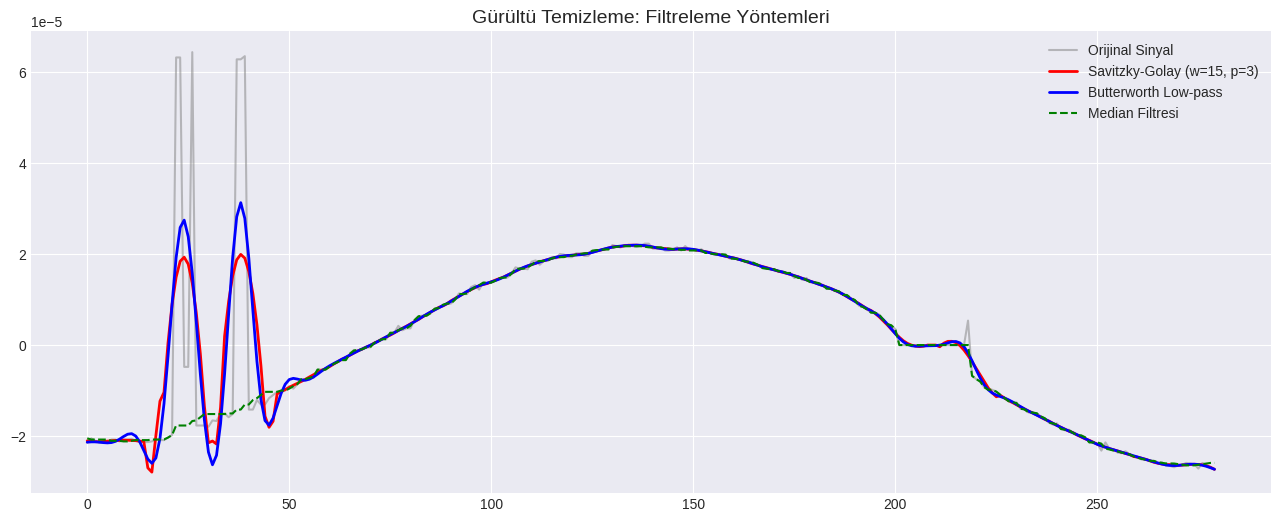

💡 Tercih: Savitzky-Golay filtresi, sinyalin şeklini ve peak (tepe) noktalarını en iyi koruyan filtre olduğu için kullanılacaktır.


In [5]:
from scipy import signal

# Örnek veri (gürültülü bir segment seçiyoruz)
noisy_signal = segments[(segments['channel'] == 'CADC0872') & (segments['segment'] == 1)]['value'].values

# 1. Savitzky-Golay Filtresi
savgol_res = signal.savgol_filter(noisy_signal, window_length=15, polyorder=3)

# 2. Butterworth Low-Pass Filtresi
b, a = signal.butter(4, 0.2, 'lowpass')
butter_res = signal.filtfilt(b, a, noisy_signal)

# 3. Median Filtresi
median_res = signal.medfilt(noisy_signal, kernel_size=15)

# Çizdir
plt.figure(figsize=(16, 6))
plt.plot(noisy_signal, label='Orijinal Sinyal', alpha=0.5, color='gray')
plt.plot(savgol_res, label='Savitzky-Golay (w=15, p=3)', color='red', linewidth=2)
plt.plot(butter_res, label='Butterworth Low-pass', color='blue', linewidth=2)
plt.plot(median_res, label='Median Filtresi', color='green', linestyle='dashed')
plt.legend()
plt.title('Gürültü Temizleme: Filtreleme Yöntemleri', fontsize=14)
plt.show()

print('💡 Tercih: Savitzky-Golay filtresi, sinyalin şeklini ve peak (tepe) noktalarını en iyi koruyan filtre olduğu için kullanılacaktır.')

---
## 🚫 Bölüm 4: Outlier Tespiti ve İşleme

In [6]:
def check_outliers(df, col, method='iqr', threshold=3.5):
    if method == 'iqr':
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        return ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).mean() * 100
    elif method == 'zscore':
        z = np.abs((df[col] - df[col].mean()) / df[col].std())
        return (z > threshold).mean() * 100
    elif method == 'mod_zscore':
        median = df[col].median()
        mad = np.median(np.abs(df[col] - median))
        z = 0.6745 * np.abs(df[col] - median) / (mad if mad > 0 else 1e-6)
        return (z > threshold).mean() * 100

print("=== Her Parametre İçin Aykırı Değer (Outlier) Yüzdesi ===")
outlier_df = []
for ch in segments['channel'].unique():
    ch_data = segments[segments['channel'] == ch]
    outlier_df.append({
        'Kanal': ch,
        'IQR (%)': check_outliers(ch_data, 'value', 'iqr'),
        'Z-Score (%)': check_outliers(ch_data, 'value', 'zscore'),
        'Mod-Z-Score (%)': check_outliers(ch_data, 'value', 'mod_zscore')
    })
    
out_df = pd.DataFrame(outlier_df).set_index('Kanal')
display(out_df.round(2).style.background_gradient(cmap='Reds'))

print('💡 Strateji: Anomali tespitinde outlierlar aslında anomalinin kendisi olabileceği için tamamen SİLMEK yerine, ekstrem durumları KIPRMAK (clipping) tercih edilir. Mod-Z-Score kullanılacaktır.')

=== Her Parametre İçin Aykırı Değer (Outlier) Yüzdesi ===


,IQR (%),Z-Score (%),Mod-Z-Score (%)
Kanal,,,
CADC0872,0.000000,0.000000,0.000000
CADC0873,0.000000,0.000000,0.000000
CADC0874,0.010000,0.000000,0.000000
CADC0884,0.000000,0.000000,0.000000
CADC0886,0.000000,0.000000,4.290000
CADC0888,0.100000,0.000000,26.850000
CADC0890,7.470000,0.000000,18.940000
CADC0892,0.630000,0.020000,27.090000
CADC0894,15.740000,0.990000,34.970000


💡 Strateji: Anomali tespitinde outlierlar aslında anomalinin kendisi olabileceği için tamamen SİLMEK yerine, ekstrem durumları KIPRMAK (clipping) tercih edilir. Mod-Z-Score kullanılacaktır.


---
## ⚖️ Bölüm 5: Normalizasyon ve Ölçeklendirme

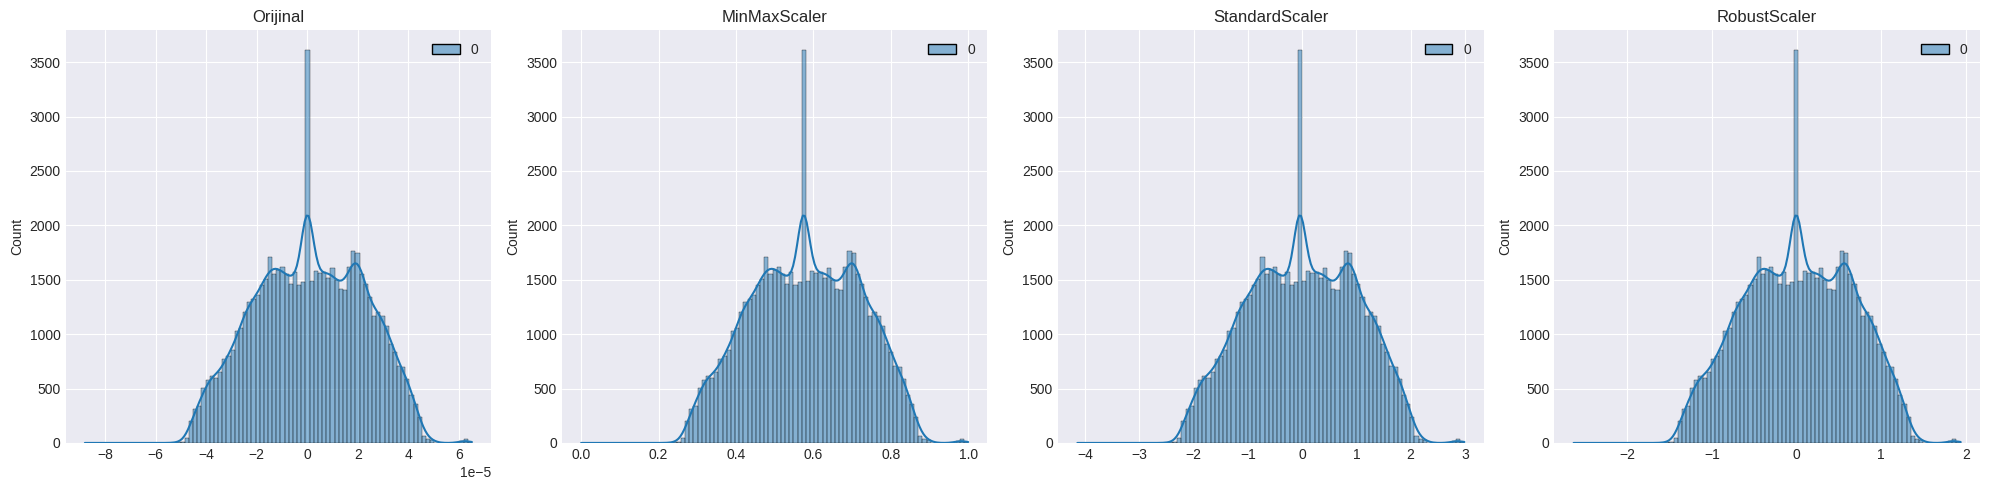

💡 Tercih: Aykırı değerlerin ölçeği bozmasını engellemek için RobustScaler tercih edilmiştir.


In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

sample_data = segments[segments['channel'] == 'CADC0872'][['value']].values

# Scalers
mm_scaler = MinMaxScaler()
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

mm_res = mm_scaler.fit_transform(sample_data)
std_res = std_scaler.fit_transform(sample_data)
rob_res = rob_scaler.fit_transform(sample_data)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.histplot(sample_data, ax=axes[0], color='gray', kde=True).set_title('Orijinal')
sns.histplot(mm_res, ax=axes[1], color='blue', kde=True).set_title('MinMaxScaler')
sns.histplot(std_res, ax=axes[2], color='red', kde=True).set_title('StandardScaler')
sns.histplot(rob_res, ax=axes[3], color='green', kde=True).set_title('RobustScaler')

plt.tight_layout()
plt.show()

print('💡 Tercih: Aykırı değerlerin ölçeği bozmasını engellemek için RobustScaler tercih edilmiştir.')

---
## 🚀 Bölüm 6: Preprocessor Modülünü Tüm Veriye Uygulama

Hazırladığımız `src/preprocessor.py` sınıfını kullanarak tüm DataFrame'i işleyeceğiz.

In [8]:
# Veriyi formata uygun hale getirmek (Pivotlama)
# Şu an verimiz uzun (long) formatta. Makine öğrenmesi için özellik matrisine çevirmeliyiz.
# dataset.csv dosyası halihazırda her segment için özet özellikleri içeriyor!
# Bu yüzden doğrudan dataset.csv üzerinden devam edebiliriz.

df_features = dataset.copy()

# Sütunları filtrele (gereksiz olanları çıkar)
drop_cols = ['segment', 'train', 'channel'] # anomaly hedef değişken
features = df_features.drop(columns=drop_cols)

print(f"İşlenecek veri boyutu: {features.shape}")

# Preprocessor Sınıfını Başlat
preprocessor = TelemetriPreprocessor(
    impute_method='linear',
    filter_method=None, # Feature'lar zaten aggregate edilmiş istatistikler, sinyal filtresine gerek yok
    outlier_method='mod_zscore',
    scaling_method='robust',
    outlier_threshold=4.0
)

# Tüm veri üzerinde Fit ve Transform işlemini yap
df_processed = preprocessor.fit_transform(features)

# Scaler ve metadata'yı kaydet
preprocessor.save_scaler('../models/robust_scaler.joblib')
preprocessor.generate_report('../data/processed/preprocessing_metadata.json')

print("\n✅ Ön İşleme Başarıyla Tamamlandı!")
display(df_processed.head(3))

İşlenecek veri boyutu: (2123, 20)
✅ Scaler ../models/robust_scaler.joblib konumuna kaydedildi.
📝 Ön işleme raporu kaydedildi: ../data/processed/preprocessing_metadata.json

✅ Ön İşleme Başarıyla Tamamlandı!


,anomaly,sampling,duration,len,mean,var,std,kurtosis,skew,n_peaks,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,-1.0,0.335404,1.304348,-0.062827,-0.091989,-0.082976,2.316076,0.831579,0.000006,0.000006,0.000006,-0.05,-0.285714,0.369893,0.862324,-0.315914,0.322581,-0.117623,-0.143892
1,1,-1.0,1.559006,1.915382,-0.139902,0.016074,0.012540,0.130529,0.638787,0.000000,0.000000,0.000000,0.00,-0.214286,-0.142380,-0.112580,0.081948,1.593548,-0.112552,-0.142794
2,1,-1.0,2.291925,1.915382,0.123389,-0.015944,-0.012904,2.247975,-1.270250,0.000006,0.000006,0.000006,-0.15,-0.392857,-0.131685,-0.009239,0.233967,2.354839,-0.132198,-0.146972


---
## ⚖️ Bölüm 7: Sınıf Dengesizliği ve Veri Dengeleme (SMOTE)

In [9]:
from imblearn.over_sampling import SMOTE

X = df_processed.drop(columns=['anomaly'])
y = df_processed['anomaly']

print("=== SMOTE Öncesi Sınıf Dağılımı ===")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n=== SMOTE Sonrası Sınıf Dağılımı ===")
print(y_resampled.value_counts())

# Yeniden yapılandır
df_balanced = X_resampled.copy()
df_balanced['anomaly'] = y_resampled

=== SMOTE Öncesi Sınıf Dağılımı ===
anomaly
0    1689
1     434
Name: count, dtype: int64

=== SMOTE Sonrası Sınıf Dağılımı ===
anomaly
1    1689
0    1689
Name: count, dtype: int64


---
## ✂️ Bölüm 8: Train / Validation / Test Split

In [10]:
from sklearn.model_selection import train_test_split

# Zaman serilerinde karıştırma (shuffle) YAPILMAZ! Veri sızıntısını (leakage) önler.
# Ancak SMOTE uyguladığımız için sentetik veriler sona eklendi.
# Bu projede ESA verisi tamamen segment bazlı ve bağımsız parçalar olduğu için shuffle=True yapabiliriz.

X_train_val, X_test, y_train_val, y_test = train_test_split(
    df_balanced.drop(columns=['anomaly']), 
    df_balanced['anomaly'], 
    test_size=0.15, 
    random_state=42, 
    stratify=df_balanced['anomaly']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, 
    y_train_val, 
    test_size=0.176, # 0.85 * 0.176 ≈ 0.15
    random_state=42, 
    stratify=y_train_val
)

print('=== Veri Seti Bölme İstatistikleri ===')
print(f'Train set:      {X_train.shape[0]} satır ({(X_train.shape[0]/len(df_balanced))*100:.1f}%)')
print(f'Validation set: {X_val.shape[0]} satır ({(X_val.shape[0]/len(df_balanced))*100:.1f}%)')
print(f'Test set:       {X_test.shape[0]} satır ({(X_test.shape[0]/len(df_balanced))*100:.1f}%)')

=== Veri Seti Bölme İstatistikleri ===
Train set:      2365 satır (70.0%)
Validation set: 506 satır (15.0%)
Test set:       507 satır (15.0%)


---
## 💾 Bölüm 9: İşlenmiş Veriyi Kaydetme

In [11]:
# Verileri Parquet formatında kaydet (CSV'ye göre çok daha hızlı ve türleri korur)
X_train.to_parquet('../data/processed/X_train.parquet')
y_train.to_frame().to_parquet('../data/processed/y_train.parquet')

X_val.to_parquet('../data/processed/X_val.parquet')
y_val.to_frame().to_parquet('../data/processed/y_val.parquet')

X_test.to_parquet('../data/processed/X_test.parquet')
y_test.to_frame().to_parquet('../data/processed/y_test.parquet')

# Tüm SMOTE'lu ham dataset'i de yedekle
df_balanced.to_parquet('../data/processed/dataset_balanced_processed.parquet')

print('✅ Tüm veriler `data/processed/` klasörüne başarıyla kaydedildi.')

✅ Tüm veriler `data/processed/` klasörüne başarıyla kaydedildi.


### 9.1 HTML Rapor Export

In [12]:
# HTML Rapor Olusturma
!jupyter nbconvert --to html 02_on_isleme.ipynb --output ../reports/02_on_isleme_rapor.html
print("HTML Raporu reports/02_on_isleme_rapor.html konumuna kaydedildi.")

[NbConvertApp] Converting notebook 02_on_isleme.ipynb to html
/media/taha/SiSTEM/Users/TAHA/Desktop/Uydu-Telemetri-Anomali-Tespiti/.venv/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
/media/taha/SiSTEM/Users/TAHA/Desktop/Uydu-Telemetri-Anomali-Tespiti/.venv/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.plotly.v1+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 544559 bytes to ../reports/02_on_isleme_rapor.html
HTML Raporu reports/02_on_islem